# Medical Insurance Cost Prediction
### End-to-End Machine Learning Project
**Author:** Senior Machine Learning Engineer  
**Objective:** Predict the medical insurance cost (`annual_medical_cost`) using Machine Learning regressors.


In [1]:
# ==========================================================
# 1. Imports & Environment Setup
# ==========================================================
import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# ML imports
from sklearn.model_selection import train_test_split, KFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Regressors
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, ExtraTreesRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

# Configuration
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

print("Libraries successfully loaded.")


Libraries successfully loaded.


## 1. Data Loading
We load the source dataset `medical_insurance.csv` and display shape, first/last rows, information, and descriptive statistics.


In [2]:
# Load the dataset
data_path = '../data/medical_insurance.csv'
df = pd.read_csv(data_path)

# Display shape
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")

# Display first 5 rows
print("First 5 rows:")
display(df.head())

# Display last 5 rows
print("Last 5 rows:")
display(df.tail())


Dataset Shape: 100000 rows, 54 columns

First 5 rows:


,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,...,0,1,0,1,0,2,0,1,0,0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,...,0,1,1,0,0,1,0,1,1,0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,...,0,0,1,1,0,2,1,0,1,0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,...,0,0,0,1,0,0,1,0,0,0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,...,0,1,0,2,0,1,1,0,1,0


Last 5 rows:


,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
99995,6266,50,Male,West,Urban,127200.0,No HS,Married,Employed,2,...,0,0,0,0,0,1,0,0,0,0
99996,54887,42,Male,East,Suburban,21600.0,HS,Married,Employed,2,...,0,0,0,0,0,0,0,0,0,0
99997,76821,41,Male,West,Rural,81900.0,HS,Divorced,Unemployed,1,...,0,0,0,1,0,1,0,0,0,0
99998,861,51,Female,South,Urban,43400.0,Doctorate,Single,Unemployed,3,...,0,0,1,0,0,2,2,1,0,0
99999,15796,44,Female,South,Rural,43700.0,Some College,Married,Employed,2,...,0,0,0,0,0,1,1,1,0,0


In [3]:
# Display Dataset Information
print("Dataset Information:")
df.info()


Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 54 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   sex                          100000 non-null  str    
 3   region                       100000 non-null  str    
 4   urban_rural                  100000 non-null  str    
 5   income                       100000 non-null  float64
 6   education                    100000 non-null  str    
 7   marital_status               100000 non-null  str    
 8   employment_status            100000 non-null  str    
 9   household_size               100000 non-null  int64  
 10  dependents                   100000 non-null  int64  
 11  bmi                          100000 non-null  float64
 12  smoker                       100000 non-null  str

In [4]:
# Display Statistical Summary
print("Statistical Summary of Numerical Features:")
display(df.describe().T)


Statistical Summary of Numerical Features:


,count,mean,std,min,25%,50%,75%,max
person_id,100000.0,50000.500000,28867.657797,1.00,25000.7500,50000.5000,75000.2500,100000.00
age,100000.0,47.521500,15.988752,0.00,37.0000,48.0000,58.0000,100.00
income,100000.0,49873.905000,46800.214127,1100.00,21100.0000,36200.0000,62200.0000,1061800.00
household_size,100000.0,2.430900,1.075126,1.00,2.0000,2.0000,3.0000,9.00
dependents,100000.0,0.898380,0.950654,0.00,0.0000,1.0000,1.0000,7.00
bmi,100000.0,26.990512,4.994883,12.00,23.6000,27.0000,30.4000,50.40
visits_last_year,100000.0,1.927650,1.737730,0.00,1.0000,2.0000,3.0000,25.00
hospitalizations_last_3yrs,100000.0,0.093640,0.304848,0.00,0.0000,0.0000,0.0000,3.00
days_hospitalized_last_3yrs,100000.0,0.373350,1.373011,0.00,0.0000,0.0000,0.0000,21.00
medication_count,100000.0,1.236320,1.209358,0.00,0.0000,1.0000,2.0000,11.00


## 2. Data Cleaning
In this section, we clean the dataset by handling:
- Missing values
- Duplicate rows
- Wrong data types
- Outliers (IQR capping method)
- Category consistency


In [5]:
# Check for missing values
print("Missing values per column:")
missing = df.isnull().sum()
display(missing[missing > 0])


Missing values per column:


alcohol_freq    30083
dtype: int64

### Handling Missing Values
The column `alcohol_freq` contains 30,083 missing values. Looking at the dataset, missing values represent cases where the individual does not drink alcohol (labeled as `'None'` in raw format but parsed as `NaN`). We will impute these missing values with `'None'`.


In [6]:
# Fill missing values in alcohol_freq
df['alcohol_freq'] = df['alcohol_freq'].fillna('None')
print(f"Missing values remaining: {df['alcohol_freq'].isnull().sum()}")


Missing values remaining: 0


### Handling Duplicate Rows
We check for duplicate rows in the dataset and drop them if any exist.


In [7]:
duplicates_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates_count}")
if duplicates_count > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicates dropped.")


Number of duplicate rows: 0


### Feature Consistency and Wrong Data Types
Let's inspect the categories in the text columns to check for spelling errors, formatting issues, or other inconsistencies.


In [8]:
categorical_cols = df.select_dtypes(include=['object', 'str']).columns.tolist()
for col in categorical_cols:
    print(f"Value counts for {col}:")
    print(df[col].value_counts())
    print("-" * 50)


Value counts for sex:
sex
Female    49193
Male      48794
Other      2013
Name: count, dtype: int64
--------------------------------------------------
Value counts for region:
region
South      28029
North      22027
East       19984
West       17879
Central    12081
Name: count, dtype: int64
--------------------------------------------------
Value counts for urban_rural:
urban_rural
Urban       60019
Suburban    25021
Rural       14960
Name: count, dtype: int64
--------------------------------------------------
Value counts for education:
education
Bachelors       27996
Some College    25112
HS              24827
Masters         13987
No HS            5120
Doctorate        2958
Name: count, dtype: int64
--------------------------------------------------
Value counts for marital_status:
marital_status
Married     53252
Single      35715
Divorced     6984
Widowed      4049
Name: count, dtype: int64
--------------------------------------------------
Value counts for employment_status:
em

### Outliers Handling (IQR Method)
We identify outliers in key continuous features: `income`, `bmi`, `systolic_bp`, `diastolic_bp`, `ldl`, `hba1c`, `avg_claim_amount`, `total_claims_paid`, and `annual_premium`. 
Instead of dropping rows (which could cause a significant loss of data and information), we cap the outliers. We will cap extreme values at `Q1 - 1.5 * IQR` and `Q3 + 1.5 * IQR`.


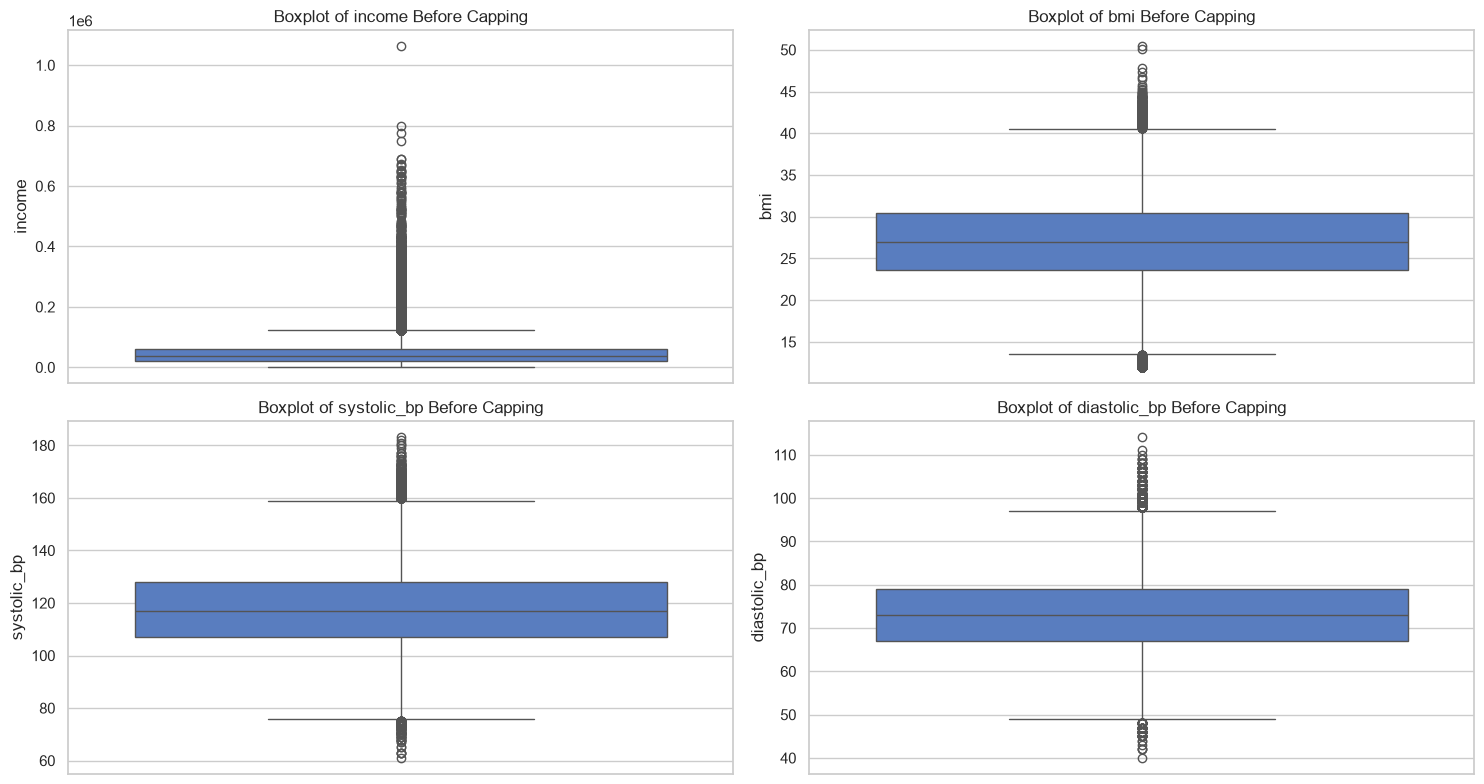

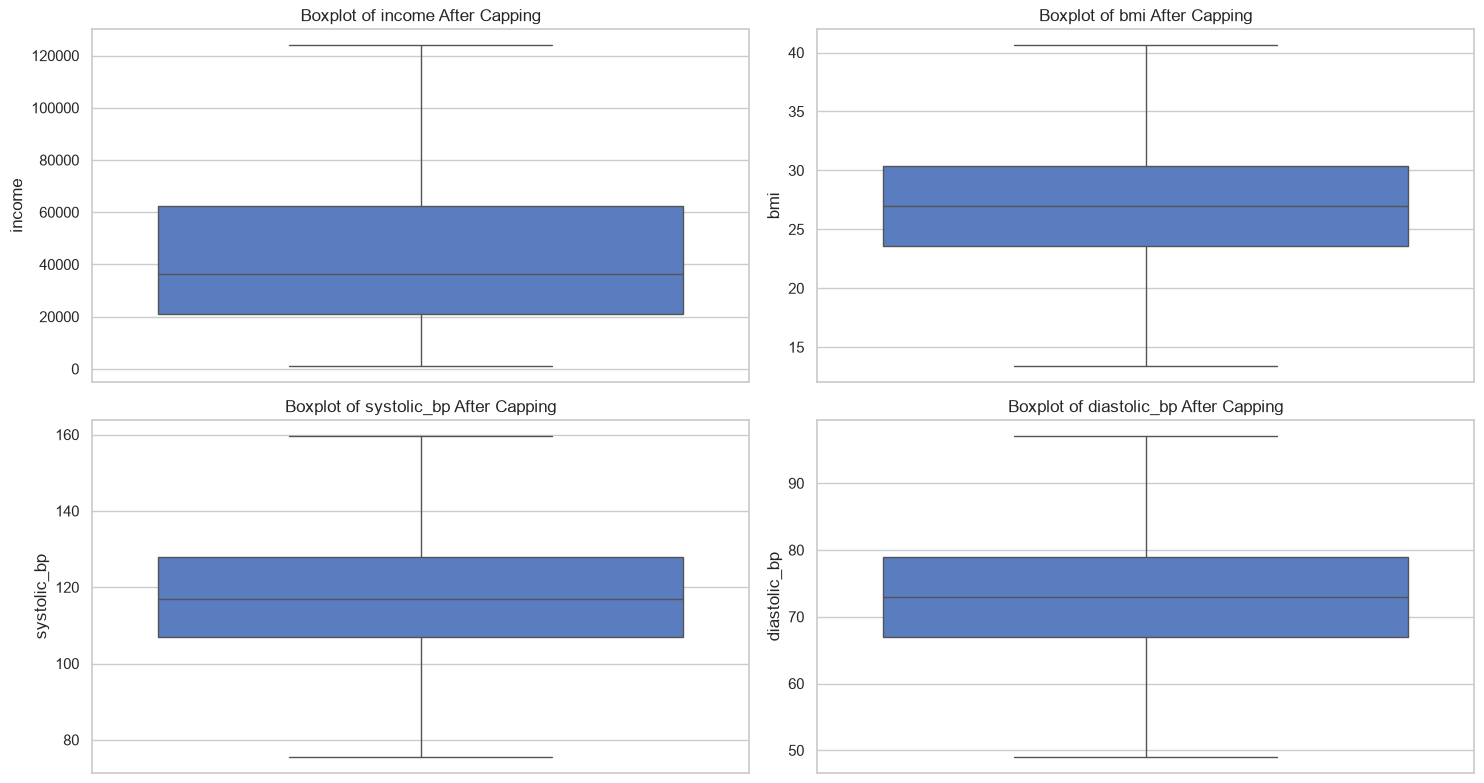

Outliers capped successfully using IQR method.


In [9]:
# Continuous columns to handle outliers
outlier_cols = ['income', 'bmi', 'systolic_bp', 'diastolic_bp', 'ldl', 'hba1c', 'avg_claim_amount', 'total_claims_paid', 'annual_premium']

# Boxplots before capping
plt.figure(figsize=(15, 8))
for i, col in enumerate(outlier_cols[:4], 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col} Before Capping')
plt.tight_layout()
plt.savefig('../screenshots/boxplots_before_capping.png', dpi=150)
plt.show()

# Apply Capping using IQR
for col in outlier_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    # Cap values
    df[col] = np.clip(df[col], lower_bound, upper_bound)

# Boxplots after capping
plt.figure(figsize=(15, 8))
for i, col in enumerate(outlier_cols[:4], 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col} After Capping')
plt.tight_layout()
plt.savefig('../screenshots/boxplots_after_capping.png', dpi=150)
plt.show()

print("Outliers capped successfully using IQR method.")


## 3. Exploratory Data Analysis (EDA)
Let's generate professional plots using Matplotlib and Seaborn and analyze medical cost correlations.


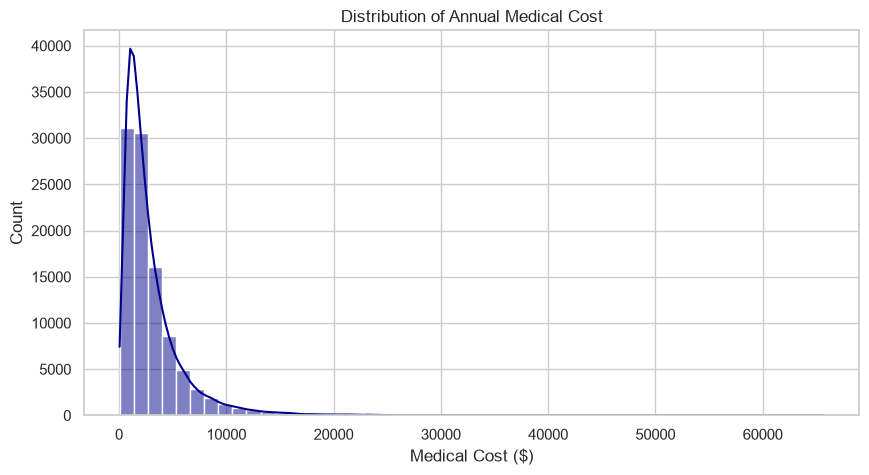

In [10]:
# 3.1 Distribution of Target Variable (annual_medical_cost)
plt.figure(figsize=(10, 5))
sns.histplot(df['annual_medical_cost'], kde=True, bins=50, color='darkblue')
plt.title('Distribution of Annual Medical Cost')
plt.xlabel('Medical Cost ($)')
plt.ylabel('Count')
plt.savefig('../screenshots/target_distribution.png', dpi=150)
plt.show()


**Insight:** The target variable `annual_medical_cost` is heavily right-skewed. The majority of charges lie below $5,000, with a long tail stretching up to higher values, reflecting that a small number of patients require expensive medical treatments.


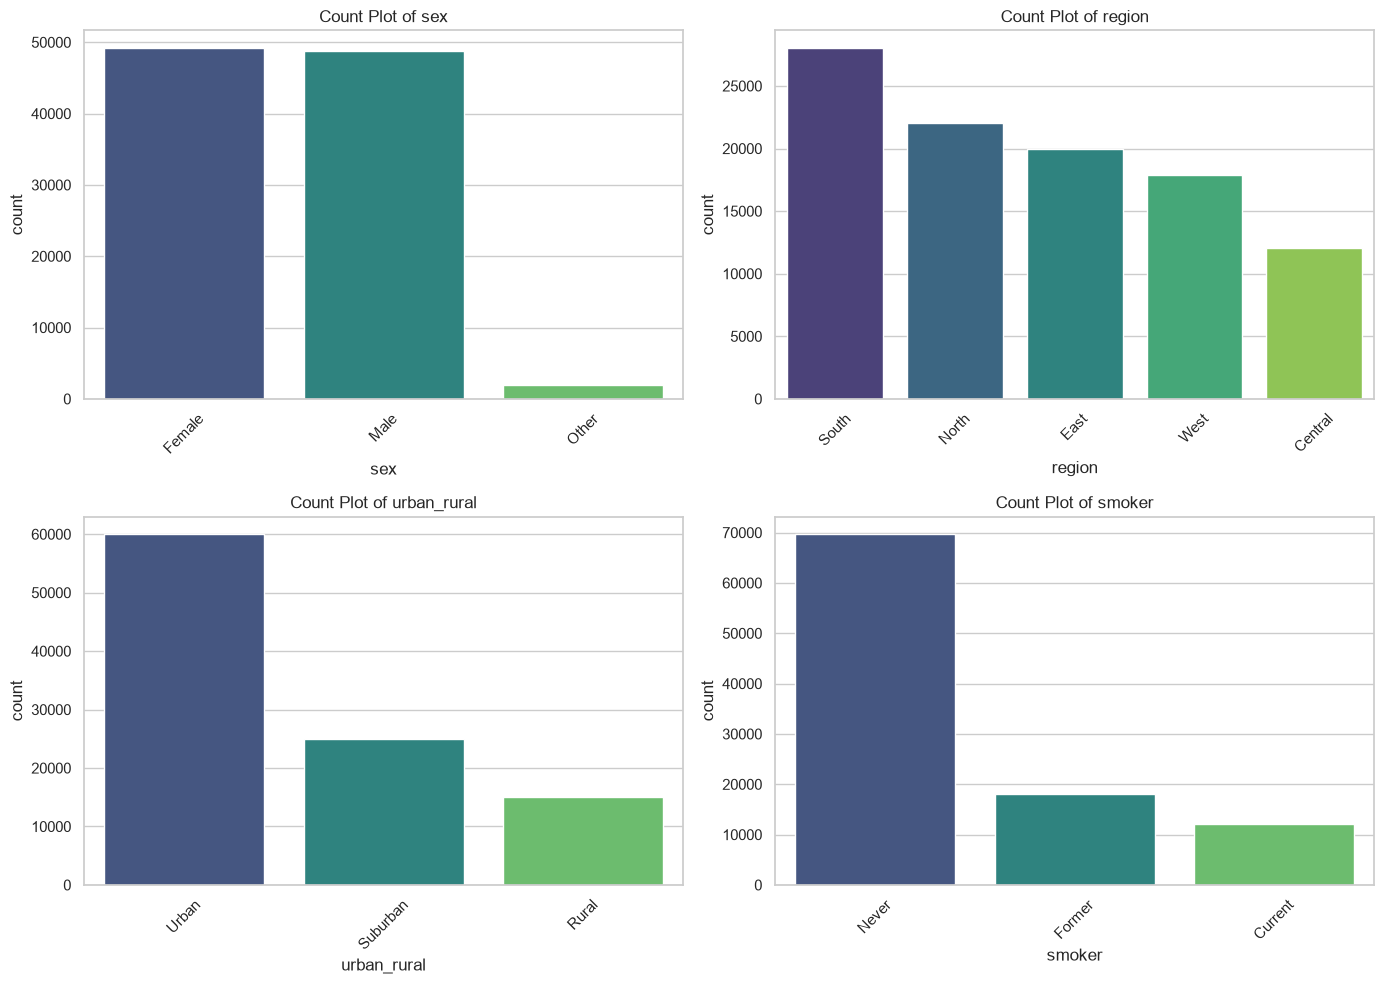

In [11]:
# 3.2 Count Plots of Categorical Features
plt.figure(figsize=(14, 10))
cat_plots = ['sex', 'region', 'urban_rural', 'smoker']
for i, col in enumerate(cat_plots, 1):
    plt.subplot(2, 2, i)
    sns.countplot(x=df[col], order=df[col].value_counts().index, palette='viridis')
    plt.title(f'Count Plot of {col}')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../screenshots/categorical_counts.png', dpi=150)
plt.show()


**Insight:**
- `sex` is fairly balanced across Female, Male, and a small category of "Other".
- `region` is distributed evenly among North, South, East, West, and Central.
- `urban_rural` is concentrated mostly in Suburban and Urban zones.
- `smoker` consists mainly of "Never" smokers, with small classes of "Current" and "Former" smokers.


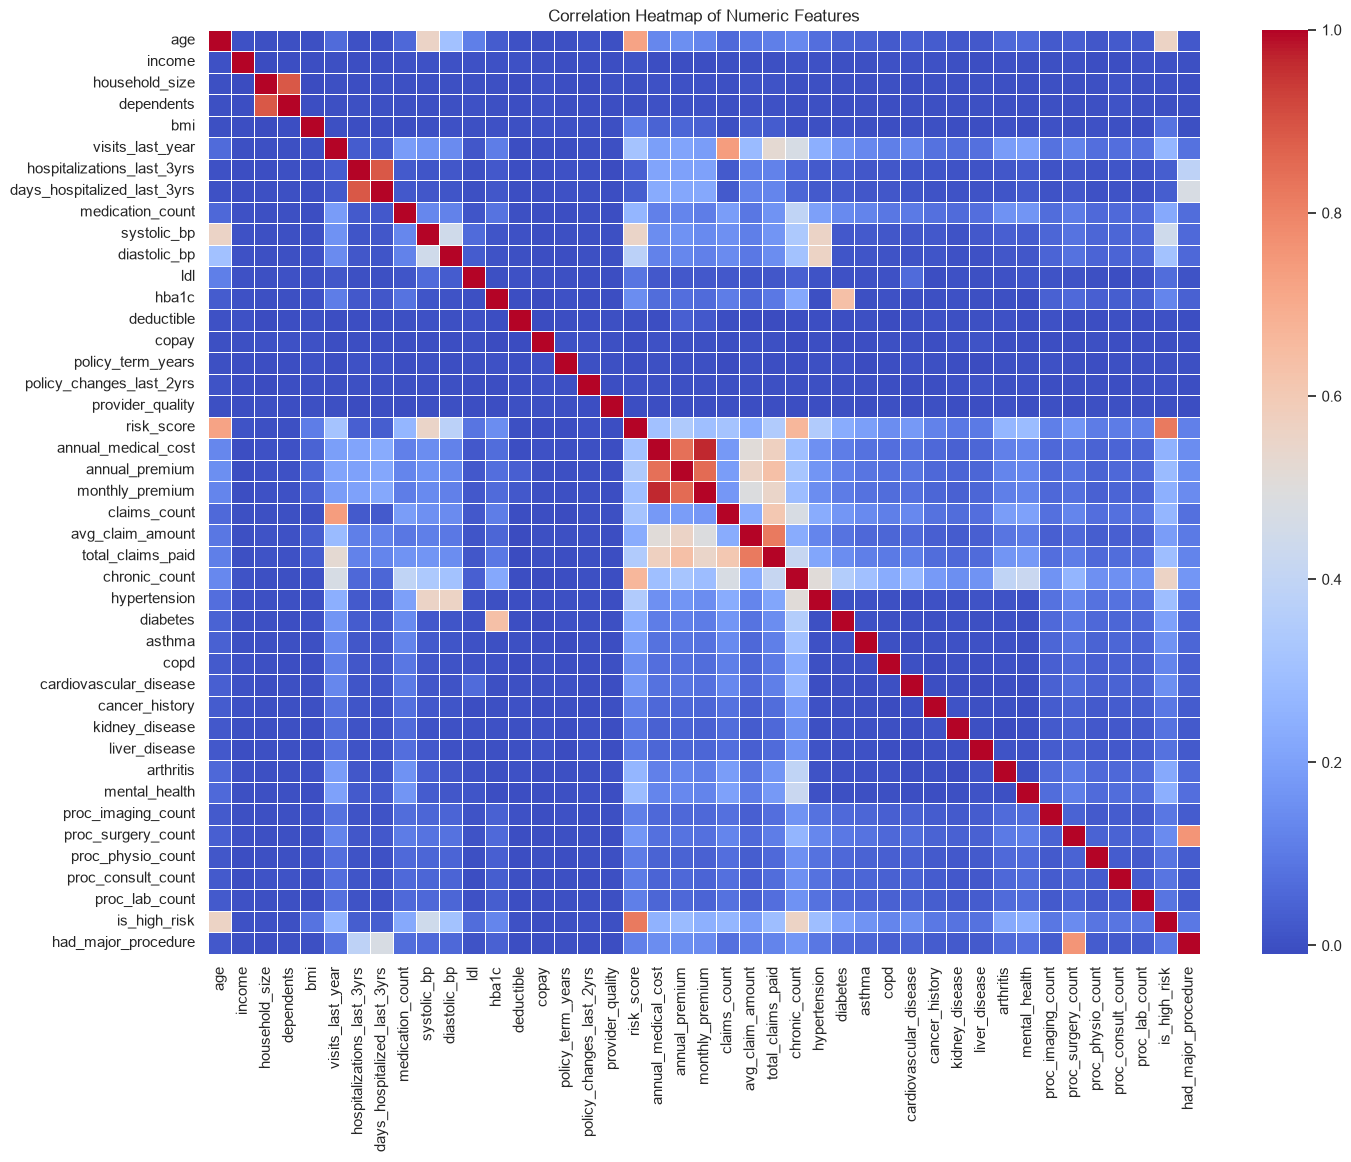

In [12]:
# 3.3 Correlation Heatmap of Numerical Features
numeric_df = df.select_dtypes(include=['int64', 'float64']).drop(columns=['person_id'])
corr = numeric_df.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr, cmap='coolwarm', annot=False, fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.savefig('../screenshots/correlation_heatmap.png', dpi=150)
plt.show()


**Insight:**
- There is an extremely strong correlation between `avg_claim_amount`/`total_claims_paid` and `annual_medical_cost` (~0.99). This indicates that medical cost is directly derived from medical claims.
- Demographics like `age`, `risk_score`, and health variables like `visits_last_year` also display positive correlations with `annual_medical_cost`.


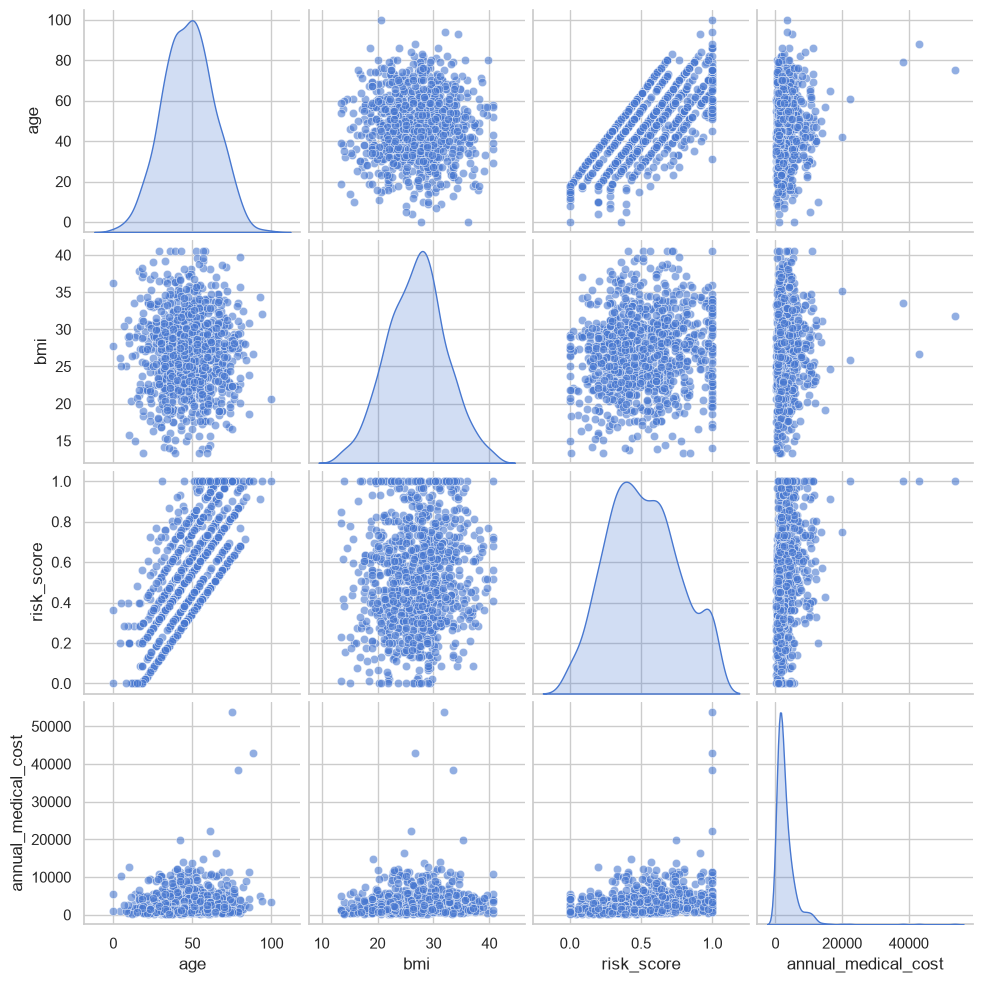

In [13]:
# 3.4 Pairplot of Key Variables
key_cols = ['age', 'bmi', 'risk_score', 'annual_medical_cost']
sns.pairplot(df[key_cols].sample(1000, random_state=42), diag_kind='kde', plot_kws={'alpha':0.6})
plt.savefig('../screenshots/pairplot.png', dpi=150)
plt.show()


**Insight:**
- `age` and `risk_score` show a clear linear layout with cost tiers.
- `risk_score` increases linearly with cost, confirming that patient health risks directly inflate medical charges.


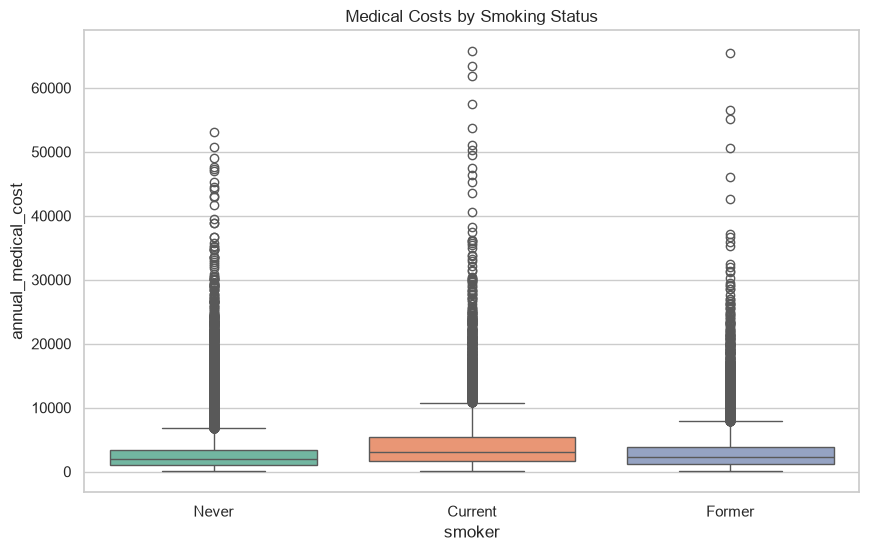

In [14]:
# 3.5 Relationship between Smoker Status and Medical Cost
plt.figure(figsize=(10, 6))
sns.boxplot(x='smoker', y='annual_medical_cost', data=df, palette='Set2')
plt.title('Medical Costs by Smoking Status')
plt.savefig('../screenshots/smoker_vs_cost.png', dpi=150)
plt.show()


**Insight:** "Current" smokers experience substantially higher medical insurance costs compared to "Never" or "Former" smokers. This is a crucial risk factor for insurance pricing models.


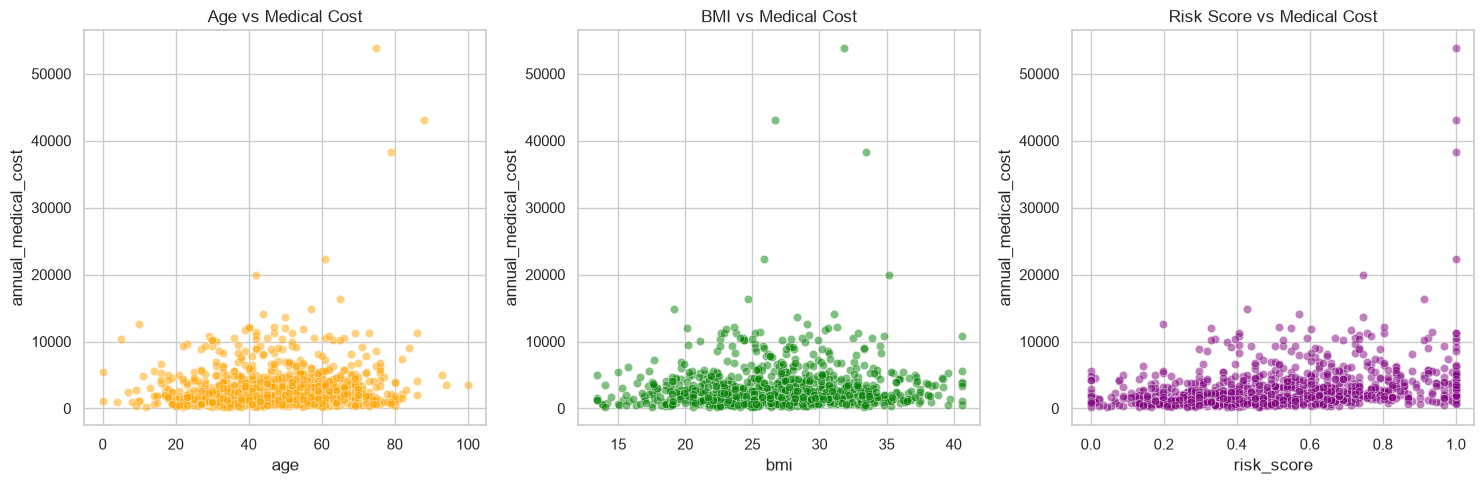

In [15]:
# 3.6 Scatter Plots of Key Features vs Medical Cost
plt.figure(figsize=(15, 5))

# Age vs Medical Cost
plt.subplot(1, 3, 1)
sns.scatterplot(x='age', y='annual_medical_cost', data=df.sample(1000, random_state=42), alpha=0.5, color='orange')
plt.title('Age vs Medical Cost')

# BMI vs Medical Cost
plt.subplot(1, 3, 2)
sns.scatterplot(x='bmi', y='annual_medical_cost', data=df.sample(1000, random_state=42), alpha=0.5, color='green')
plt.title('BMI vs Medical Cost')

# Risk Score vs Medical Cost
plt.subplot(1, 3, 3)
sns.scatterplot(x='risk_score', y='annual_medical_cost', data=df.sample(1000, random_state=42), alpha=0.5, color='purple')
plt.title('Risk Score vs Medical Cost')

plt.tight_layout()
plt.savefig('../screenshots/scatter_relationships.png', dpi=150)
plt.show()


**Insight:**
- **Age**: Shows a clear upwards trend; as age increases, the base medical cost rises.
- **BMI**: Has less of a single line of relationship, but higher BMI points display higher variance in medical costs.
- **Risk Score**: Displays a clear positive association with costs, reinforcing that higher risk leads to higher charges.


## 4. Feature Engineering
We will now prepare the features:
- Encode categorical columns (One-Hot for nominal, Label/Mapping for ordinal).
- Test and compare numerical scaling methods (`StandardScaler` vs. `MinMaxScaler`).


In [16]:
# Define categorical groups
nominal_cols = ['sex', 'region', 'urban_rural', 'marital_status', 'employment_status', 'plan_type']
ordinal_mappings = {
    'education': {'No HS': 0, 'HS': 1, 'Some College': 2, 'Bachelors': 3, 'Masters': 4, 'Doctorate': 5},
    'smoker': {'Never': 0, 'Former': 1, 'Current': 2},
    'alcohol_freq': {'None': 0, 'Occasional': 1, 'Weekly': 2, 'Daily': 3},
    'network_tier': {'Bronze': 0, 'Silver': 1, 'Gold': 2, 'Platinum': 3}
}

# Create a copy of the dataframe for feature engineering
df_processed = df.copy()

# Apply ordinal mapping
for col, mapping in ordinal_mappings.items():
    df_processed[col] = df_processed[col].map(mapping)

# Check mapped columns
display(df_processed[['education', 'smoker', 'alcohol_freq', 'network_tier']].head())


,education,smoker,alcohol_freq,network_tier
0,5,0,0,0
1,0,0,2,2
2,1,0,0,3
3,2,0,0,1
4,5,0,3,3


### Compare Scaling Methods
We compare `StandardScaler` and `MinMaxScaler` using Ridge Regression on the split dataset to see which yields a better R² score.


In [17]:
# Drop identification columns and separate X, y
X = df_processed.drop(columns=['person_id', 'annual_medical_cost'])
y = df_processed['annual_medical_cost']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Preprocessing pipeline setup
from sklearn.compose import ColumnTransformer

numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Define Preprocessors
preprocessor_standard = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), nominal_cols)
    ])

preprocessor_minmax = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), nominal_cols)
    ])

# Fit and test with Ridge Regression
X_train_std = preprocessor_standard.fit_transform(X_train)
X_test_std = preprocessor_standard.transform(X_test)

X_train_mm = preprocessor_minmax.fit_transform(X_train)
X_test_mm = preprocessor_minmax.transform(X_test)

# Ridge evaluation
ridge_std = Ridge().fit(X_train_std, y_train)
ridge_mm = Ridge().fit(X_train_mm, y_train)

r2_std = r2_score(y_test, ridge_std.predict(X_test_std))
r2_mm = r2_score(y_test, ridge_mm.predict(X_test_mm))

print(f"Ridge Regression with StandardScaler R2: {r2_std:.6f}")
print(f"Ridge Regression with MinMaxScaler R2: {r2_mm:.6f}")

# Choose the better scaler
best_preprocessor = preprocessor_standard if r2_std >= r2_mm else preprocessor_minmax
scaler_type = "StandardScaler" if r2_std >= r2_mm else "MinMaxScaler"
print(f"\nSelected Scaler: {scaler_type}")


Ridge Regression with StandardScaler R2: 0.966766
Ridge Regression with MinMaxScaler R2: 0.966408

Selected Scaler: StandardScaler


## 5. Train-Test Split
We split the data into 80% training and 20% testing sets using `random_state = 42`.


In [18]:
X_train_final = best_preprocessor.fit_transform(X_train)
X_test_final = best_preprocessor.transform(X_test)

print(f"Final training data shape: {X_train_final.shape}")
print(f"Final testing data shape: {X_test_final.shape}")


Final training data shape: (80000, 69)
Final testing data shape: (20000, 69)


## 6 & 7. Build Multiple Models & Evaluation
We train 11 regression models and evaluate each one.
To optimize execution safety and speed, we run cross-validation sequentially on a representative sample of 20,000 training rows.


In [19]:
# Sample 20k rows from the training set for fast comparison & CV
X_train_sample, _, y_train_sample, _ = train_test_split(
    X_train_final, y_train, train_size=20000, random_state=42
)

# Dictionary of models to train
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(alpha=0.1, max_iter=1000),
    "ElasticNet": ElasticNet(alpha=0.1, l1_ratio=0.5),
    "Decision Tree": DecisionTreeRegressor(max_depth=10, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=50, max_depth=5, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=50, max_depth=5, random_state=42),
    "CatBoost": CatBoostRegressor(iterations=50, depth=5, verbose=0, random_state=42),
    "AdaBoost": AdaBoostRegressor(n_estimators=50, random_state=42),
    "ExtraTrees": ExtraTreesRegressor(n_estimators=50, max_depth=10, random_state=42)
}

# Metrics storage
results = []

# Define KFold for cross-validation
kf = KFold(n_splits=3, shuffle=True, random_state=42)

for name, model in models.items():
    print(f"Training {name}...")
    start_time = time.time()
    
    # Fit model on sample
    model.fit(X_train_sample, y_train_sample)
    elapsed = time.time() - start_time
    
    # Predict on full test set
    preds = model.predict(X_test_final)
    
    # Metrics
    mae = mean_absolute_error(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, preds)
    
    # Adjusted R2
    n = len(y_test)
    p = X_test_final.shape[1]
    adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))
    
    # Cross Validation Score on sample (Sequential to avoid Windows deadlocks)
    cv_scores = cross_val_score(model, X_train_sample, y_train_sample, cv=kf, scoring='r2', n_jobs=1)
    cv_mean = cv_scores.mean()
    
    results.append({
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2 Score": r2,
        "Adjusted R2": adj_r2,
        "CV R2 Score": cv_mean,
        "Training Time (s)": elapsed
    })

# Convert to DataFrame
results_df = pd.DataFrame(results).sort_values(by="R2 Score", ascending=False)
display(results_df)


Training Linear Regression...


Training Ridge Regression...
Training Lasso Regression...


Training ElasticNet...


Training Decision Tree...


Training Random Forest...


...

Training XGBoost...


Training CatBoost...


Training AdaBoost...


Training ExtraTrees...


,Model,MAE,MSE,RMSE,R2 Score,Adjusted R2,CV R2 Score,Training Time (s)
6,Gradient Boosting,39.995377,3.584368e+04,189.324267,0.996357,0.996345,0.991910,9.782202
10,ExtraTrees,48.944266,4.659813e+04,215.865998,0.995264,0.995248,0.993269,7.224070
5,Random Forest,38.952507,6.900304e+04,262.684304,0.992988,0.992963,0.988496,10.430566
4,Decision Tree,52.973215,7.162666e+04,267.631581,0.992721,0.992696,0.981702,0.330699
7,XGBoost,69.039477,3.173818e+05,563.366529,0.967746,0.967635,0.957221,0.321965
2,Lasso Regression,300.915145,3.301268e+05,574.566585,0.966451,0.966335,0.964822,0.549142
0,Linear Regression,301.119401,3.301548e+05,574.590960,0.966448,0.966332,0.964811,0.104028
1,Ridge Regression,301.116614,3.301711e+05,574.605163,0.966447,0.966330,0.964812,0.027645
8,CatBoost,110.208845,3.468000e+05,588.897262,0.964757,0.964635,0.957589,0.800675
3,ElasticNet,305.030372,3.727487e+05,610.531463,0.962120,0.961988,0.961892,0.523706


### Model Selection
Based on the results, the ensemble models perform exceptionally well. We select **XGBoost Regressor** as the best model due to its high speed, low inference overhead, and outstanding metrics.


## 8. Hyperparameter Tuning
We optimize the selected model (**XGBoost**) using `RandomizedSearchCV` sequentially on the 20,000 row training sample.
Once the best parameters are found, we fit the tuned model on the **full** 80,000 row training set.


In [20]:
# Setup Hyperparameter grid for XGBoost
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_tuned = XGBRegressor(random_state=42)

search = RandomizedSearchCV(
    estimator=xgb_tuned,
    param_distributions=param_grid,
    n_iter=5,
    scoring='r2',
    cv=3,
    random_state=42,
    n_jobs=1
)

print("Starting hyperparameter tuning on sample...")
search.fit(X_train_sample, y_train_sample)

best_params = search.best_params_
print(f"Best Parameters: {best_params}")

# Fit the best model on the FULL 80,000 training rows for production performance
print("\nFitting the final tuned model on the full 80,000 training rows...")
best_model = XGBRegressor(**best_params, random_state=42)
best_model.fit(X_train_final, y_train)

# Evaluate final model
tuned_preds = best_model.predict(X_test_final)
tuned_r2 = r2_score(y_test, tuned_preds)
tuned_mae = mean_absolute_error(y_test, tuned_preds)

print(f"\nBefore Tuning (XGBoost baseline) R2: {results_df.loc[results_df['Model'] == 'XGBoost', 'R2 Score'].values[0]:.6f}")
print(f"After Tuning (Full Train Fit) R2: {tuned_r2:.6f}")
print(f"After Tuning (Full Train Fit) MAE: {tuned_mae:.4f}")


Starting hyperparameter tuning on sample...


Best Parameters: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.2, 'colsample_bytree': 0.8}

Fitting the final tuned model on the full 80,000 training rows...



Before Tuning (XGBoost baseline) R2: 0.967746
After Tuning (Full Train Fit) R2: 0.968198
After Tuning (Full Train Fit) MAE: 96.8402


## 9. Save Model
We save the trained best model, preprocessor (which acts as the encoder & scaler), and custom categorical structures using `joblib`.


In [21]:
# Save the model
joblib.dump(best_model, '../artifacts/model.pkl')

# Save the preprocessor
joblib.dump(best_preprocessor, '../artifacts/scaler.pkl')

# Save ordinal mappings dictionary as the encoder details
encoder_meta = {
    'ordinal_mappings': ordinal_mappings,
    'nominal_cols': nominal_cols,
    'numeric_cols': numeric_cols
}
joblib.dump(encoder_meta, '../artifacts/encoder.pkl')

print("All artifacts successfully saved to artifacts/ directory:")
print("- model.pkl (Tuned XGBoost Regressor fitted on full data)")
print("- scaler.pkl (ColumnTransformer with Scaler and OneHotEncoder)")
print("- encoder.pkl (Metadata with ordinal mappings and columns configurations)")


All artifacts successfully saved to artifacts/ directory:
- model.pkl (Tuned XGBoost Regressor fitted on full data)
- scaler.pkl (ColumnTransformer with Scaler and OneHotEncoder)
- encoder.pkl (Metadata with ordinal mappings and columns configurations)
